## ANN (artificial neural network) for Classification

Now that we have the demo under our belt, let's see how to use ANN for a _real_ problem. We will make a model that can detect if an imagine was edited with a _sepia filter_ or not.

In [3]:
from datasets import load_from_disk

dataset = load_from_disk("./data/filtered_dataset")

Even though I made that dataset, you are not magicle so you don't know how the data looks like. So let's plot it and make sure we are all on the same page. Okey dokey?

You need to keep in mind that 0 means the imagine is edited with a sepia filter, 1 means the imagine is not edited with a sepia filter.

Because we only have two classes this is more of a binary classification problem so we don't need softmax at the end of our model, we can just use sigmoid. But I will still use softmax because it's a more general approach. You can also use sigmoid if you want, but I will stick with softmax for this one.

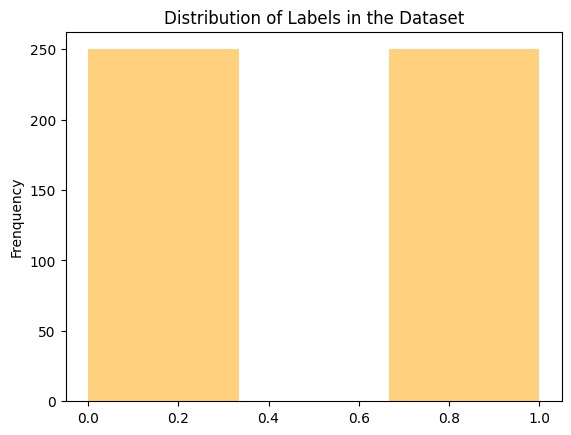

In [8]:
from matplotlib import pyplot as plt

plt.hist(dataset['label'], bins=3, alpha=0.5, color='orange')
plt.ylabel('Frenquency')
plt.title('Distribution of Labels in the Dataset')
plt.show()

In [4]:
import numpy as np
from tqdm import tqdm
import cv2

def normalize_image_to_array(image):
	img = np.array(image).astype(np.uint8)
	img = cv2.resize(img, (64, 64)) # is you fallow thie homework, do this in the database_maker.py when making the dataset, not here
	img_1D = img.flatten()
	return img_1D / 255.0

# dataset = dataset.map(process, num_proc=4)  # uses 4 CPU cores
X = np.array([normalize_image_to_array(img) for img in tqdm(dataset['image'])])
Y = dataset['label']

100%|██████████| 500/500 [16:50<00:00,  2.02s/it]


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = MLPClassifier(
  	hidden_layer_sizes=(128, 64),
  	activation='relu', 
  	max_iter=1000, 
  	verbose=True,
	random_state=42
)

# this is so much faster, when i sow how long the normalization took, i was shaking in my boots
model.fit(X_train, Y_train)

Iteration 1, loss = 0.99724441
Iteration 2, loss = 6.17616045
Iteration 3, loss = 2.58749396
Iteration 4, loss = 4.04867335
Iteration 5, loss = 1.22829337
Iteration 6, loss = 1.84526297
Iteration 7, loss = 0.87085487
Iteration 8, loss = 1.10252000
Iteration 9, loss = 0.78353684
Iteration 10, loss = 0.85452443
Iteration 11, loss = 0.66417300
Iteration 12, loss = 0.72008936
Iteration 13, loss = 0.61845587
Iteration 14, loss = 0.65800694
Iteration 15, loss = 0.58173417
Iteration 16, loss = 0.61916098
Iteration 17, loss = 0.57543121
Iteration 18, loss = 0.58685668
Iteration 19, loss = 0.56637978
Iteration 20, loss = 0.55999631
Iteration 21, loss = 0.54976858
Iteration 22, loss = 0.54752333
Iteration 23, loss = 0.54874501
Iteration 24, loss = 0.54059232
Iteration 25, loss = 0.54011106
Iteration 26, loss = 0.52565475
Iteration 27, loss = 0.54170332
Iteration 28, loss = 0.53525779
Iteration 29, loss = 0.53619557
Iteration 30, loss = 0.52981614
Iteration 31, loss = 0.52492218
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


              precision    recall  f1-score   support

           0       0.78      0.85      0.82        47
           1       0.86      0.79      0.82        53

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.82       100
weighted avg       0.82      0.82      0.82       100



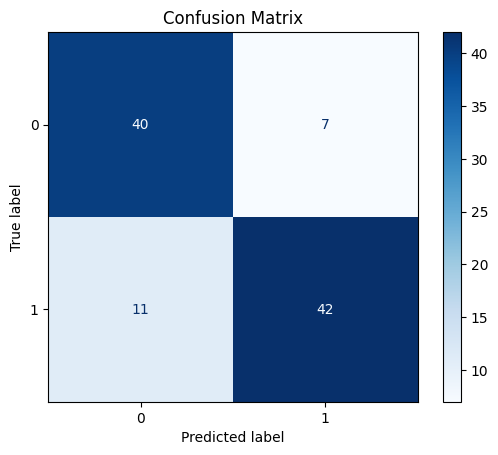

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

Y_pred = model.predict(X_test)
print(classification_report(Y_test, Y_pred))

cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

### Opinion on the rezults...

First of all, what do I think the model is doing? Well, I think it's just calculationg how "warm" the imagine is. If it's very warm, then it's probably a sepia filter, if it's not very warm, then it's probably not a sepia filter. So I think the model is just learning to detecting "hey the sum of the red and green channels is higher than the blue channel, then it's probably a sepia filter".

Now let's test this hypothesis by giving it two pis I took and lets see if it can label them correctly. 

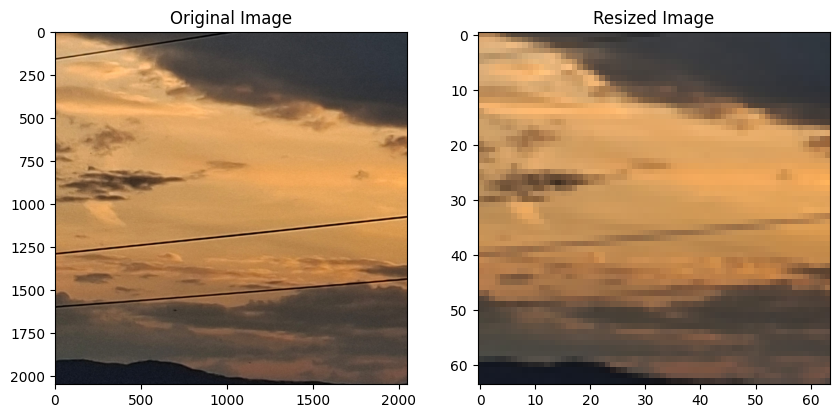

Prediction for the first test image: no edited with confidence of 97.5%
  - Sepia Filter: 2.5%
  - No Filter:    97.5%


In [6]:
from PIL import Image

test_one = Image.open("./data/sun_pic.jpeg")
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(test_one)
ax[0].set_title("Original Image")

# im curiosus to see how the imagine looks resize
test_one_resized = test_one.resize((64, 64))
ax[1].imshow(test_one_resized)
ax[1].set_title("Resized Image")
plt.show()

test_one_array = normalize_image_to_array(test_one)
test_one_pred = model.predict([test_one_array])
test_one_proba = model.predict_proba([test_one_array])

print(f"Prediction for the first test image: {"no edited" if test_one_pred[0] == 1 else "sepia filter"} with confidence of {max(test_one_proba[0]) * 100:.1f}%")
print(f"  - Sepia Filter: {test_one_proba[0][0] * 100:.1f}%")
print(f"  - No Filter:    {test_one_proba[0][1] * 100:.1f}%")

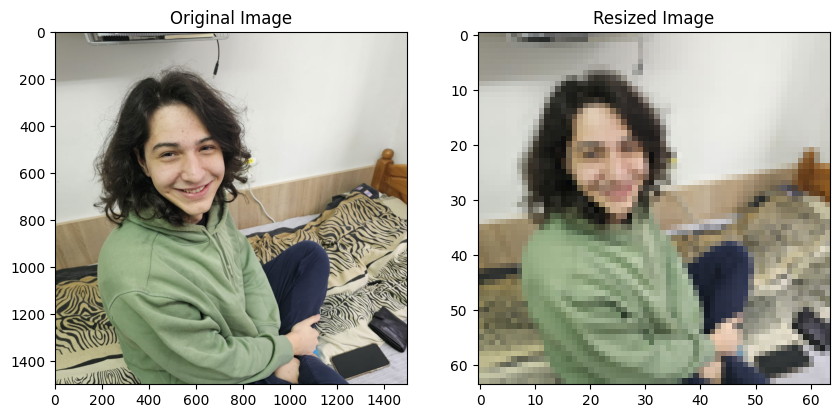

Prediction for the second test image: no edited with confidence of 99.9%
  - Sepia Filter: 0.1%
  - No Filter:    99.9%


In [7]:
test_two = Image.open("./data/me_pic.jpeg")
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(test_two)
ax[0].set_title("Original Image")

# im curiosus to see how the imagine looks resize
test_two_resized = test_two.resize((64, 64))
ax[1].imshow(test_two_resized)
ax[1].set_title("Resized Image")
plt.show()

test_two_array = normalize_image_to_array(test_two)
test_two_pred = model.predict([test_two_array])
test_two_proba = model.predict_proba([test_two_array])

print(f"Prediction for the second test image: {"no edited" if test_two_pred[0] == 1 else "sepia filter"} with confidence of {max(test_two_proba[0]) * 100:.1f}%")
print(f"  - Sepia Filter: {test_two_proba[0][0] * 100:.1f}%")
print(f"  - No Filter:    {test_two_proba[0][1] * 100:.1f}%")

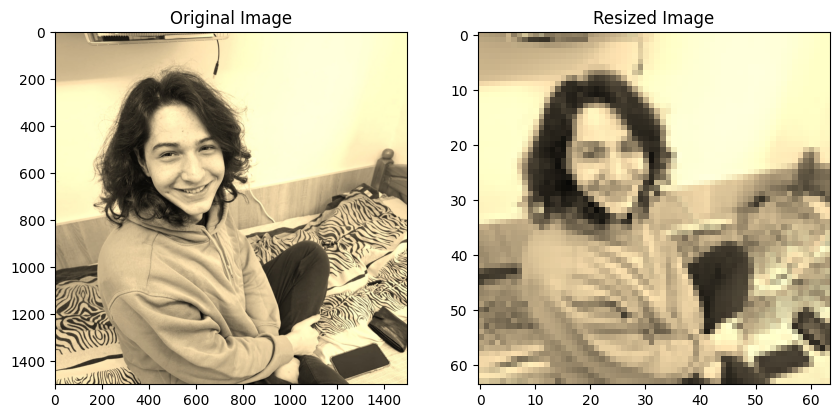

Prediction for the third test image: sepia filter with confidence of 100.0%
  - Sepia Filter: 100.0%
  - No Filter:    0.0%


In [8]:
test_three = Image.open("./data/me_sepia_pic.jpg")
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(test_three)
ax[0].set_title("Original Image")

# im curiosus to see how the imagine looks resize
test_three_resized = test_three.resize((64, 64))
ax[1].imshow(test_three_resized)
ax[1].set_title("Resized Image")
plt.show()

test_three_array = normalize_image_to_array(test_three)
test_three_pred = model.predict([test_three_array])
test_three_proba = model.predict_proba([test_three_array])

print(f"Prediction for the third test image: {"no edited" if test_three_pred[0] == 1 else "sepia filter"} with confidence of {max(test_three_proba[0]) * 100:.1f}%")
print(f"  - Sepia Filter: {test_three_proba[0][0] * 100:.1f}%")
print(f"  - No Filter:    {test_three_proba[0][1] * 100:.1f}%")

### Conclusion

Even though the model predicted my tests correctly, I know it's not that good. And my first hypothesis might be correct even if my "worm" picture didn't seem to fool the model.

---

### Hyperparameters in Machine Learning

Hyperparameters are the settings or configurations that you choose before training a machine learning model. They are not learned from the data but are set by the practitioner. Hyperparameters can significantly affect the performance of a model, and finding the right combination of hyperparameters is often crucial for achieving good results.

Here you **goober**, this is what i read: [Hyperparameters in Machine Learning](https://medium.com/@etimfonime/hyperparameters-in-machine-learning-c8b06dde7a31)

I know your lazy ass ain't reading that... cough... _Cristian_... cough... so this you need to know
> Hyperparameter tuning is a critical step in building effective machine learning models. Understanding how key hyperparameters like C in SVM, max_depth in Decision Trees, or alpha in Ridge Regression affect performance will help you make informed choices.

Also this is realy cool, in the documentation of sklearn, they talk about paramiters (the ones we'll use) and have cool grafs: [Sklearn neural network](https://scikit-learn.org/stable/modules/neural_networks_supervised.html#regularization)

<img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_mlp_alpha_001.png" alt="SKLEARN documentation pic" width="1000">

---

```py
# most are my default set
model = MLPClassifier(
    # Network architecture
    hidden_layer_sizes=(256, 128, 64),   # layers, getting smaller toward output
    activation='relu',                   # 'relu', 'tanh', 'logistic'
    
    # Training
    learning_rate_init=0.001,            # how big the weight update steps are
    max_iter=50,                         # number of epochs
    batch_size=32,                       # images per update step
    
    # Regularization (prevents overfitting)
    alpha=0.0001,                        # L2 penalty, increase if overfitting
    early_stopping=True,                 # stops if validation score stops improving
    n_iter_no_change=10,                 # stops after 10 epochs with no improvement
    
    random_state=42,
    verbose=True
)
```

+ Learning rate is about speed, too high and it overshoots, too low and it takes forever
+ Alpha is about complexity, too low and it memorizes, too high and it oversimplifies

Without alpha the model might learn "this exact shade of brown means no filter", with alpha it learns "warm tones in general mean no filter

$$ w = w - \eta \cdot (\frac{\partial L}{\partial w} + 2 \alpha w) $$

In [9]:
from sklearn.model_selection import GridSearchCV

params = {
    'hidden_layer_sizes': [(128, 64), (256, 128), (256, 128, 64)],
    'alpha': [0.0001, 0.001, 0.01],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
}

grid = GridSearchCV(MLPClassifier(max_iter=50, early_stopping=True), params, verbose=2)
grid.fit(X_train, Y_train)

print("Best params:", grid.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64), learning_rate_init=0.001; total time=   3.7s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64), learning_rate_init=0.001; total time=   3.4s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64), learning_rate_init=0.001; total time=   2.3s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64), learning_rate_init=0.001; total time=   3.9s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64), learning_rate_init=0.001; total time=   1.7s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64), learning_rate_init=0.01; total time=   4.2s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64), learning_rate_init=0.01; total time=   5.6s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64), learning_rate_init=0.01; total time=   2.4s
[CV] END activation=r

              precision    recall  f1-score   support

           0       0.61      0.91      0.74        47
           1       0.87      0.49      0.63        53

    accuracy                           0.69       100
   macro avg       0.74      0.70      0.68       100
weighted avg       0.75      0.69      0.68       100



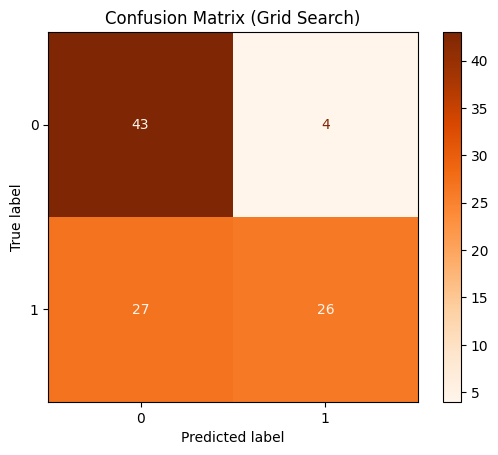

In [10]:
Y_pred_grid = grid.predict(X_test)
print(classification_report(Y_test, Y_pred_grid))

cm_grid = confusion_matrix(Y_test, Y_pred_grid)
disp_grid = ConfusionMatrixDisplay(confusion_matrix=cm_grid, display_labels=model.classes_).plot(cmap='Oranges')
plt.title('Confusion Matrix (Grid Search)')
plt.show()

Yes, the results are worse, but this is because we only trained for 50 epochs, i will take the parmaiters from the "best model" and train it for 1000 like ew did for the original and see if it gets better.

In [13]:
model_best = MLPClassifier(
  	hidden_layer_sizes=(256, 128),
    learning_rate_init=0.001,
    alpha=0.01,
  	activation='relu', 
    early_stopping=True,
  	max_iter=1000, 
	random_state=42
)

model_best.fit(X_train, Y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(256, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.01
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


              precision    recall  f1-score   support

           0       0.60      0.98      0.74        47
           1       0.96      0.42      0.58        53

    accuracy                           0.68       100
   macro avg       0.78      0.70      0.66       100
weighted avg       0.79      0.68      0.66       100



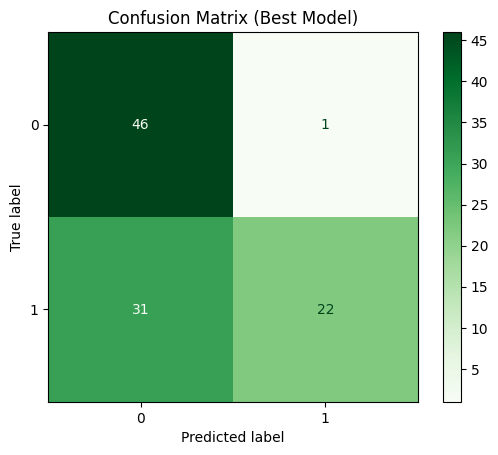

In [19]:
model_best_pred = model_best.predict(X_test)
print(classification_report(Y_test, model_best_pred))
cm_best = confusion_matrix(Y_test, model_best_pred)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=model.classes_).plot(cmap='Greens')
plt.title('Confusion Matrix (Best Model)')
plt.show()

**OMFG** it's worse! 😭😭😭😭😭😱😂😖🔫⚰️💀

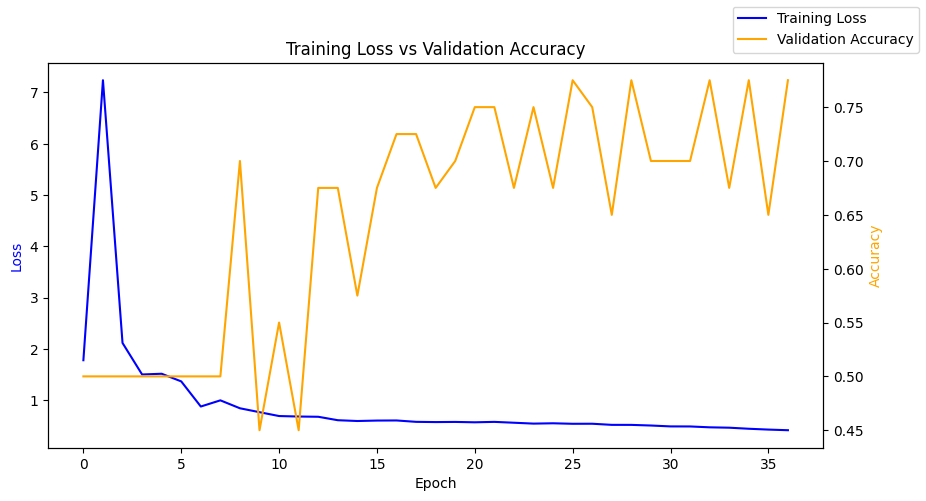

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(model_best.loss_curve_, label='Training Loss', color='blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='blue')

ax2 = ax1.twinx()  # second y-axis
ax2.plot(model_best.validation_scores_, label='Validation Accuracy', color='orange')
ax2.set_ylabel('Accuracy', color='orange')

fig.legend(loc='upper right')
plt.title('Training Loss vs Validation Accuracy')
plt.show()

In [21]:
model_best_v2 = MLPClassifier(
  	hidden_layer_sizes=(256, 128),
    learning_rate_init=0.0001,
    alpha=0.01,
  	activation='relu', 
    early_stopping=True,
  	max_iter=1000, 
	random_state=42
)

model_best_v2.fit(X_train, Y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(256, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.01
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.0001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


              precision    recall  f1-score   support

           0       0.56      0.72      0.63        47
           1       0.67      0.49      0.57        53

    accuracy                           0.60       100
   macro avg       0.61      0.61      0.60       100
weighted avg       0.62      0.60      0.60       100



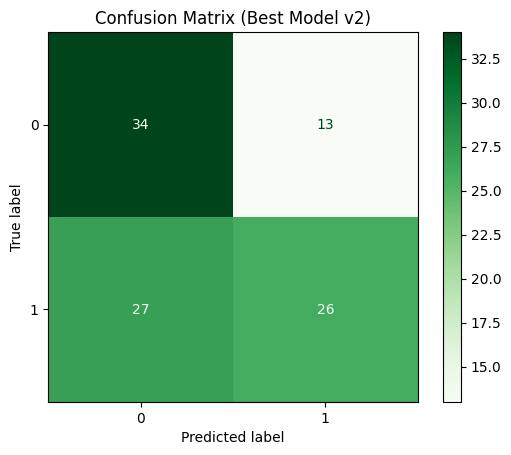

In [22]:
model_best_v2_pred = model_best_v2.predict(X_test)
print(classification_report(Y_test, model_best_v2_pred))
cm_best_v2 = confusion_matrix(Y_test, model_best_v2_pred)
disp_best_v2 = ConfusionMatrixDisplay(confusion_matrix=cm_best_v2, display_labels=model.classes_).plot(cmap='Greens')
plt.title('Confusion Matrix (Best Model v2)')
plt.show()

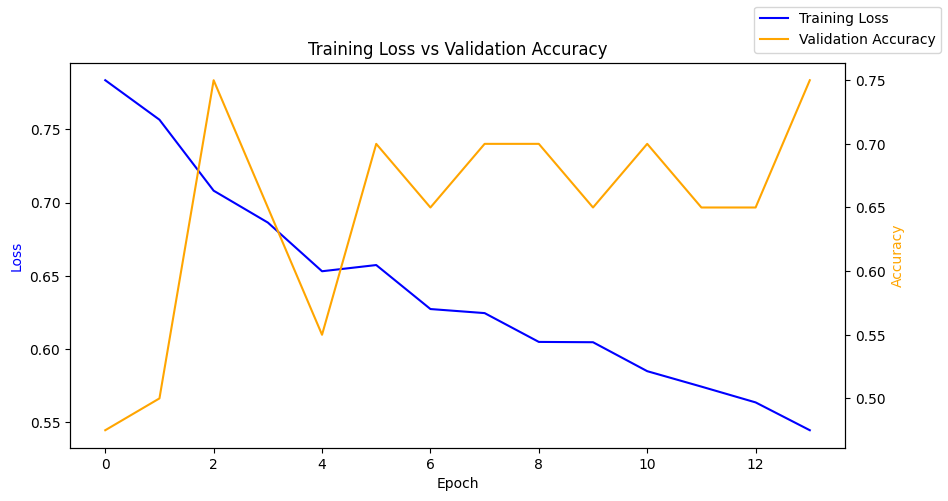

In [23]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(model_best_v2.loss_curve_, label='Training Loss', color='blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='blue')

ax2 = ax1.twinx()  # second y-axis
ax2.plot(model_best_v2.validation_scores_, label='Validation Accuracy', color='orange')
ax2.set_ylabel('Accuracy', color='orange')

fig.legend(loc='upper right')
plt.title('Training Loss vs Validation Accuracy')
plt.show()

IDK man, I'm lost, I don't get why it's getting worse